# Build a target model (the model DAG)

Every `skysurvey` target draws its parameters (redshift, stretch, color, magnitude, position...) following a **model**:
a plain python `dict` that tells which function generates which parameter, and how parameters depend on each other.
In this tutorial you will build such a model step by step, from a single parameter to a full SN Ia-like model
with a host-mass dependency, and then use it in a {class}`skysurvey.SNeIa` target.

:::{note}
The modelling engine is the [modeldag](https://github.com/MickaelRigault/modeldag) package, installed together with `skysurvey`.
:::

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy import stats

import modeldag
import skysurvey

rng = np.random.default_rng(42) # used for the reproducible draws of this notebook

## The concept

To generate `data`, the code reads the **model** entry by entry and follows the instructions it contains.
Each entry is a `name: {...}` item that accepts 3 keywords:

1. `func`: the function (or the name of a function) used to draw the parameter, e.g. `rng.uniform` ;
2. `kwargs`: the options given to `func`. A value written as `"@key"` means "use the already drawn `key` column as input" ;
3. `as`: the name (or list of names) of the resulting column(s) in `data`. If not given, the entry name is used.

Only `func` is really needed (see below for exceptions). The resulting `data` is a {class}`pandas.DataFrame`
with one row per target and at least one column per entry.

## A one-parameter model

Let's start with the simplest possible model: a single parameter `x1` (the SALT2 stretch of a SN Ia lightcurve)
drawn from a normal distribution. The model is given to `modeldag.ModelDAG`, which knows how to draw it.

In [2]:
model = {"x1": {"func": rng.normal, "kwargs": {"loc": 0, "scale": 1}}}

dag = modeldag.ModelDAG(model)
dag.draw(size=5)

,x1
0,0.304717
1,-1.039984
2,0.750451
3,0.940565
4,-1.951035


`size` is passed to `func` automatically: `func` must accept a `size` argument and return `size` values,
as numpy's or scipy's random functions do.

Adding an independent parameter is as simple as adding an entry. Here we add the SALT2 color `c`:

In [3]:
model = {"x1": {"func": rng.normal, "kwargs": {"loc": 0, "scale": 1}},
         "c":  {"func": rng.normal, "kwargs": {"loc": 0, "scale": 0.1}},
        }

modeldag.ModelDAG(model).draw(size=5)

,x1,c
0,0.304717,-0.130218
1,-1.039984,0.012784
2,0.750451,-0.031624
3,0.940565,-0.001680
4,-1.951035,-0.085304


## Adding dependencies with "@"

Parameters are rarely independent. For instance, the absolute magnitude of a SN Ia depends on its stretch and color,
following the Tripp (1998) relation $M = M_0 + \alpha\,x_1 + \beta\,c$ (plus some intrinsic scatter).
Hence, once `x1` and `c` have been drawn, the absolute magnitude `magabs` can be obtained using them as inputs.

This is what the `"@"` trick in `kwargs` does: `"@x1"` is replaced by the drawn `x1` column.
Here we use the Tripp relation implemented in {meth}`skysurvey.SNeIaMagnitude.tripp1998`.

In [4]:
model = {"x1": {"func": rng.normal, "kwargs": {"loc": 0, "scale": 1}},
         "c":  {"func": rng.normal, "kwargs": {"loc": 0, "scale": 0.1}},
         "magabs": {"func": skysurvey.SNeIaMagnitude.tripp1998,
                    "kwargs": {"x1": "@x1", "c": "@c", "mabs": -19.3, "sigmaint": 0.1}},
        }

dag = modeldag.ModelDAG(model)
dag.draw(size=5, rng=rng)

,x1,c,magabs
0,0.304717,-0.130218,-19.722375
1,-1.039984,0.012784,-19.218131
2,0.750451,-0.031624,-19.429634
3,0.940565,-0.001680,-19.342915
4,-1.951035,-0.085304,-19.490667


A few things to notice:

- when an input comes from `"@"`, `size` is **not** passed to `func`: the number of values is set by the input columns ;
- the `rng` given to `draw()` is forwarded to every `func` that accepts an `rng` argument (like `tripp1998`), which makes the draw reproducible. Prefer a `numpy.random.Generator` over an integer seed: an integer would re-seed every function identically, making their random draws correlated ;
- the order of the entries in the dict does not matter: `modeldag` sorts them so that each entry is drawn after its inputs.

The connections created by the `"@key"` inputs form a [directed acyclic graph](https://en.wikipedia.org/wiki/Directed_acyclic_graph) (DAG),
hence the name *modeldag*. The dependencies are stored in the `ModelDAG` object:

In [5]:
dag.entry_dependencies # entry -> its input (NaN for root entries)

entry
x1        NaN
c         NaN
magabs     x1
magabs      c
Name: input, dtype: str

## Multiple outputs and renaming with "as"

Some functions return several parameters at once. For instance, {func}`skysurvey.tools.utils.random_radec`
draws sky coordinates and returns both `ra` and `dec`. Use `as` to name the output columns.
`as` is also useful to simply rename an entry: below, the entry `redshift` produces a column named `z`.

In [6]:
model_radec = {"redshift": {"func": rng.uniform, "kwargs": {"low": 0, "high": 0.1}, "as": "z"},
               "radec": {"func": skysurvey.tools.random_radec,
                         "kwargs": {"dec_range": [-30, 90]}, # e.g. a northern survey
                         "as": ["ra", "dec"]},
              }

modeldag.ModelDAG(model_radec).draw(size=5, rng=rng)

,z,ra,dec
0,0.097562,351.224047,3.221550
1,0.076114,274.010293,62.891785
2,0.078606,282.983150,27.761859
3,0.012811,46.120908,47.234801
4,0.045039,162.138938,9.504281


Other entries then refer to the *output* names, e.g. `"@z"`, `"@ra"` or `"@dec"`.

## Using your own function

Any python function can be used as `func`. There are three flavours.

### A function returning samples

The function returns the drawn values. Without `"@"` input it must accept `size`, and it may accept `rng`
to be reproducible. With `"@"` inputs, it receives arrays and returns an array of the same length.
Let's make the absolute magnitude depend on the host stellar mass, with a "mass step": targets in hosts more massive
than $10^{10}$ solar masses are brighter by `step` mag.

In [7]:
def magabs_with_massstep(hostmass, mabs=-19.3, sigma=0.15, step=0.1, split=10, rng=None):
    # normal scatter around mabs, with an offset for high-mass hosts.
    rng = np.random.default_rng(rng)
    magabs = rng.normal(loc=mabs, scale=sigma, size=len(hostmass))
    magabs[hostmass > split] -= step # brighter = smaller magnitude
    return magabs

### A function returning a PDF

Often, a parameter distribution is easier to write as a probability density function (PDF) than as a sampler.
If `func` has an `xx` argument, `modeldag` assumes it returns `(xx, pdf(xx))` and draws the samples from this PDF.
`xx` can be an array, or a string such as `"7:12:0.01"`, which is understood as `np.r_[7:12:0.01]`.

Here is a skewed normal distribution for the host mass (in $\log_{10}(M_*/M_\odot)$):

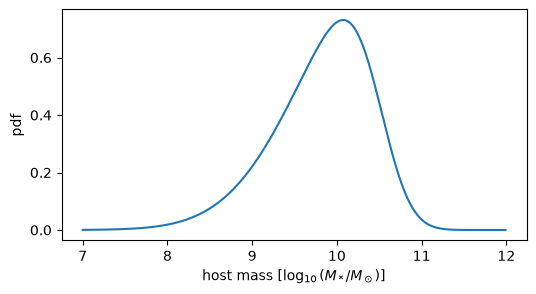

In [8]:
def hostmass_pdf(xx="7:12:0.01", loc=10.5, scale=0.9, skewness=-3):
    # skewed normal pdf of the host stellar mass (log10 Msun).
    if type(xx) is str: # assumed np.r_ input
        xx = eval(f"np.r_[{xx}]")
    return xx, stats.skewnorm.pdf(xx, skewness, loc=loc, scale=scale)

xx, pdf = hostmass_pdf()
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(xx, pdf)
ax.set(xlabel=r"host mass [$\log_{10}(M_*/M_\odot)$]", ylabel="pdf");

Both functions can now enter the model, connected with `"@hostmass"`:

In [9]:
model_host = {"hostmass": {"func": hostmass_pdf},
              "magabs": {"func": magabs_with_massstep,
                         "kwargs": {"hostmass": "@hostmass", "step": 0.15}},
             }

data = modeldag.ModelDAG(model_host).draw(size=2_000, rng=rng)
data.head()

,hostmass,magabs
0,9.41,-19.335375
1,9.97,-19.346005
2,8.83,-19.284296
3,10.37,-19.195512
4,10.08,-19.651053


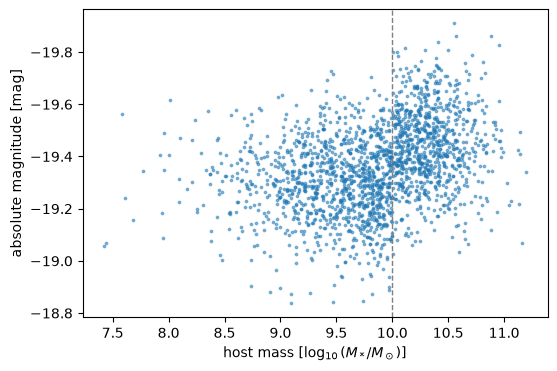

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(data["hostmass"], data["magabs"], s=3, alpha=0.5)
ax.axvline(10, color="0.5", ls="--", lw=1)
ax.set(xlabel=r"host mass [$\log_{10}(M_*/M_\odot)$]", ylabel="absolute magnitude [mag]")
ax.invert_yaxis();

### A string: a method of the target

`func` can also be a string. When the model is attached to an object (as it is in a `skysurvey` target),
the string is the name of a method of that object. For instance, all targets have a
{meth}`~skysurvey.Target.magabs_to_magobs` method converting an absolute magnitude into an observed one,
given the redshift and the target's cosmology:

```python
"magobs": {"func": "magabs_to_magobs", "kwargs": {"z": "@z", "magabs": "@magabs"}}
```

If `func` is not given at all, the object's `draw_{entry}` method is used, if it exists.
This is how {class}`skysurvey.TSTransient` draws its `redshift` entry with
{meth}`~skysurvey.Transient.draw_redshift`, following the transient rate.

## Using the model in a target

Every target class stores its default model in the `_MODEL` class attribute. Let's have a look at that of {class}`skysurvey.SNeIa`:

In [11]:
for name, entry in skysurvey.SNeIa._MODEL.items():
    func = entry.get("func")
    funcname = getattr(func, "__qualname__", func) # function name, or the string itself
    print(f"{name:>8}: func={funcname}, kwargs={entry.get('kwargs', {})}, as={entry.get('as', name)}")

redshift: func=draw_redshift, kwargs={'zmax': 0.2}, as=z
      x1: func=SNeIaStretch.nicolas2021, kwargs={}, as=x1
       c: func=SNeIaColor.intrinsic_and_dust, kwargs={}, as=c
      t0: func=Generator.uniform, kwargs={'low': 56000, 'high': 56200}, as=t0
  magabs: func=SNeIaMagnitude.tripp1998, kwargs={'x1': '@x1', 'c': '@c', 'mabs': -19.3, 'sigmaint': 0.1}, as=magabs
  magobs: func=magabs_to_magobs, kwargs={'z': '@z', 'magabs': '@magabs'}, as=magobs
   radec: func=random_radec, kwargs={}, as=['ra', 'dec']


### Changing the model while drawing

The `model` argument of {meth}`~skysurvey.Target.from_draw` updates the default model: existing
entries are replaced and new ones are added. Let's give the SNe Ia a host mass and replace their absolute magnitude
by the Tripp relation *plus* a mass step ({meth}`skysurvey.SNeIaMagnitude.tripp_and_massstep`).
In this function, targets above `split` (default 10) get `+gamma/2` and the others `-gamma/2`, so a negative `gamma`
makes SNe Ia in high-mass hosts brighter:

In [12]:
massstep_model = {"hostmass": {"func": hostmass_pdf},
                  "magabs": {"func": skysurvey.SNeIaMagnitude.tripp_and_massstep,
                             "kwargs": {"x1": "@x1", "c": "@c", "hostmass": "@hostmass",
                                        "mabs": -19.3, "sigmaint": 0.1, "gamma": -0.15}},
                 }

snia = skysurvey.SNeIa.from_draw(size=3_000, model=massstep_model, zmax=0.1)
snia.data.head()

,z,x1,c,t0,ra,dec,hostmass,magabs,magobs,template
0,0.06025,-1.560,0.037,56036.925781,156.227448,18.766327,7.88,-18.892076,18.336100,salt2
1,0.06655,1.170,0.056,56027.695312,178.454056,-69.608391,9.47,-19.276550,18.177132,salt2
2,0.07545,0.155,-0.016,56164.289062,309.496216,-20.467779,9.02,-19.134886,18.604698,salt2
3,0.09875,0.605,0.108,56025.113281,346.142822,60.579739,8.63,-19.146255,19.211855,salt2
4,0.07975,-0.055,0.093,56006.996094,134.328049,31.514206,10.62,-18.986181,18.880146,salt2


The model of the instance is a `modeldag.ModelDAG`, accessible as `snia.model`; the dict is
`snia.model.model`. Use {meth}`~skysurvey.Target.get_model` to get a copy of the model,
sorted in drawing order:

In [13]:
list(snia.get_model())

['redshift', 'x1', 'c', 't0', 'radec', 'hostmass', 'magabs', 'magobs']

:::{tip}
To only change some options of existing entries (e.g. `zmax` of `redshift` or `low`/`high` of `t0`), you do not need
to rewrite the entry: pass them as keyword arguments, e.g. `skysurvey.SNeIa.from_draw(size=1000, t0={"low": 59000, "high": 59100})`.
See [change the model while drawing](../howto/change_model_while_draw.ipynb).
:::

### Creating a new target class

If you want to reuse your model, create a new class inheriting from an existing one and set its `_MODEL`.
Here, the new class keeps all the SNe Ia entries and adds/replaces those of `massstep_model`:

In [14]:
class SNeIaMassStep(skysurvey.SNeIa):
    _KIND = "SNIa-massstep"
    _MODEL = skysurvey.SNeIa._MODEL | massstep_model

snia_step = SNeIaMassStep.from_draw(size=3_000, zmax=0.1)
snia_step.data[["z", "x1", "c", "hostmass", "magabs", "magobs"]].head()

,z,x1,c,hostmass,magabs,magobs
0,0.09425,0.060,0.322,9.46,-18.132620,20.117706
1,0.09765,1.610,-0.085,9.35,-19.757126,18.575073
2,0.06565,-1.055,0.040,9.69,-18.992500,18.430256
3,0.09675,-1.640,-0.163,9.40,-19.499743,18.811050
4,0.08535,-0.865,0.102,10.15,-18.944876,19.077074


## Visualize the model DAG

The graph of the model can be drawn from its entries and their connections (`entry_inputof`).
Here we use [networkx](https://networkx.org/) and order the nodes by "generation": root parameters
on the left, then the parameters that depend on them, etc.

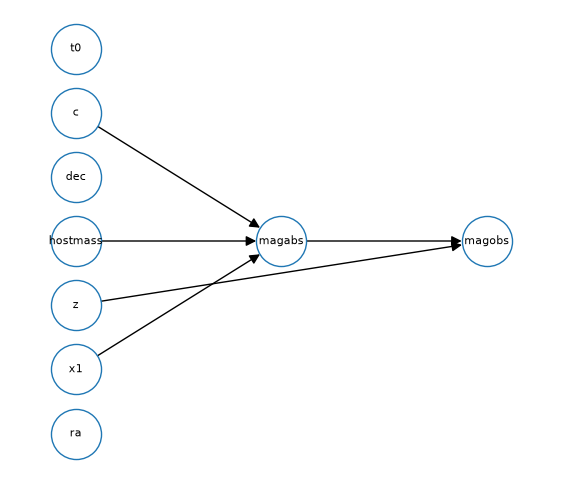

In [15]:
def show_dag(dag, ax=None):
    # draw a ModelDAG as a left-to-right graph
    graph = nx.DiGraph()
    graph.add_nodes_from(dag.entries)
    graph.add_edges_from(dag.entry_inputof.items()) # (input, entry) pairs
    for layer, nodes in enumerate(nx.topological_generations(graph)):
        for node in nodes:
            graph.nodes[node]["layer"] = layer
    pos = nx.multipartite_layout(graph, subset_key="layer")
    nx.draw_networkx(graph, pos=pos, ax=ax, node_color="w", edgecolors="C0",
                     node_size=1300, font_size=8, arrowsize=15)
    if ax is not None:
        ax.margins(0.1)
        ax.axis("off")

fig, ax = plt.subplots(figsize=(7, 6))
show_dag(snia_step.model, ax=ax)

:::{note}
If [pygraphviz](https://pygraphviz.github.io/) is installed, `snia_step.model.visualize()` displays a nicer graph
(with `incl_param=True` to also show the parameters of each entry). Beware that it writes a `tmp_modelvisualize.svg`
file in the current directory (use the `fileout` argument to change it).
:::

## Inspect the drawn data

Finally, check that the drawn targets behave as expected. {meth}`~skysurvey.Target.show_scatter`
is a quick way to look at the relation between two parameters; the `bins` option shows the binned mean.
The 0.15 mag step at $10^{10}\,M_\odot$ appears on top of the color and stretch dependencies:

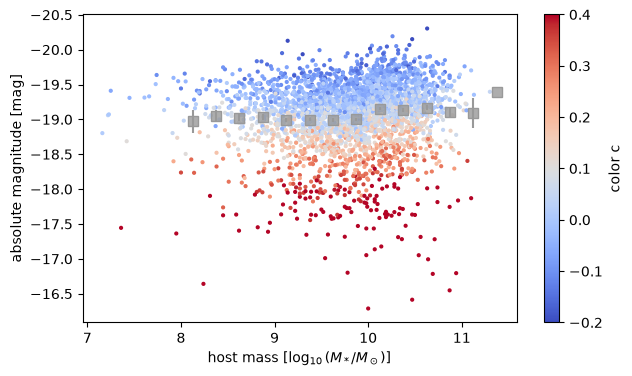

In [16]:
fig = snia_step.show_scatter("hostmass", "magabs", ckey="c", s=4, cmap="coolwarm",
                             bins=np.linspace(8, 11.5, 15), vmin=-0.2, vmax=0.4)
ax = fig.axes[0]
ax.set(xlabel=r"host mass [$\log_{10}(M_*/M_\odot)$]", ylabel="absolute magnitude [mag]")
ax.invert_yaxis()
fig.axes[1].set_ylabel("color c");

To isolate the step, look at the *standardized* magnitude, i.e. the absolute magnitude corrected for the stretch and color
terms of the Tripp relation (here with the default $\alpha=-0.14$ and $\beta=3.15$):

high-mass minus low-mass: -0.151 mag


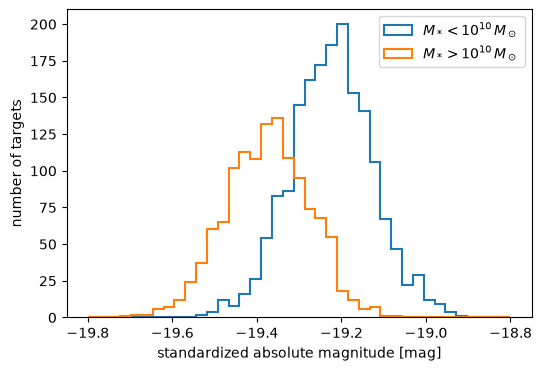

In [17]:
data = snia_step.data
mag_std = data["magabs"] - (-0.14 * data["x1"] + 3.15 * data["c"])
highmass = data["hostmass"] > 10

fig, ax = plt.subplots(figsize=(6, 4))
prop = dict(bins=np.linspace(-19.8, -18.8, 40), histtype="step", lw=1.5)
ax.hist(mag_std[~highmass], label=r"$M_* < 10^{10}\,M_\odot$", **prop)
ax.hist(mag_std[highmass], label=r"$M_* > 10^{10}\,M_\odot$", **prop)
ax.set(xlabel="standardized absolute magnitude [mag]", ylabel="number of targets")
ax.legend()
print(f"high-mass minus low-mass: {mag_std[highmass].mean() - mag_std[~highmass].mean():+.3f} mag")

## Next steps

- [Build a new transient](build_a_new_transient.ipynb): combine a model, a non-volumetric rate and a template into a new transient class.
- [Change the model while drawing](../howto/change_model_while_draw.ipynb): tweak model options on the fly.
- [Change the rate](../howto/change_rate.ipynb): control how many targets are drawn as a function of redshift.
- [SNe Ia](../transientclasses/sne_ia.ipynb): the pre-defined SN Ia model in detail.